# Neural Network Training for Lorenz63

This notebook trains neural networks to predict Lorenz63 time series using fixed system parameters (σ=10, ρ=28, β=8/3). We:
- Generate data with chosen dt, st, T
- Build supervised sliding-window datasets
- Train an ESN (Echo State Network) readout
- Evaluate one-step and free-run multi-step forecasts

Optionally, add an LSTM baseline later for comparison.

In [1]:
# Imports and config
import sys, os
import numpy as np
import pandas as pd
import torch
import skorch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from skorch import NeuralNetRegressor
from sklearn.model_selection import GridSearchCV

# Local imports
sys.path.append(os.path.abspath(".."))
from time_series.data_util import lorenz63_rhs, rk4_step, simulate_lorenz63
from model.esn import ESNRegressor, make_sliding_windows, standardize_sequences, rollout_free_run

# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print("Device:", device)


Device: cpu


In [2]:
# Data generation helpers

def simulate_lorenz63_with_sampling(T=15000, dt=0.01, st=1, x0=(1.0, 1.0, 1.0)):
    """Generate Lorenz63 trajectory using RK4 with sampling every st steps."""
    out = np.zeros((T, 3), dtype=np.float64)
    s = np.array(x0, dtype=np.float64)
    for t in range(T):
        for _ in range(st):
            s = rk4_step(lorenz63_rhs, s, dt)
        out[t] = s
    return out

# Chosen hyperparameters (update from hyperparam_search results if needed)
dt = 0.01
st = 1
T  = 15000
x0 = (1.0, 1.0, 1.0)

# Simulate
data = simulate_lorenz63_with_sampling(T=T, dt=dt, st=st, x0=x0)
print("Data:", data.shape, "range x:", (data[:,0].min(), data[:,0].max()))

# Build dataset
SEQ_LEN = 20
HORIZON = 1
WASHOUT = 500
X, y = make_sliding_windows(data, seq_len=SEQ_LEN, horizon=HORIZON, washout=WASHOUT)
print("X, y:", X.shape, y.shape)

# Train/test split (time-ordered)
N_test = 3000
X_train, X_test = X[:-N_test], X[-N_test:]
y_train, y_test = y[:-N_test], y[-N_test:]

# Standardize
X_train_std, X_test_std, y_train_std, y_test_std, x_scaler, y_scaler = standardize_sequences(
    X_train, X_test, y_train, y_test
)



Data: (15000, 3) range x: (-18.211487014544797, 19.555040676585282)
X, y: (14480, 20, 3) (14480, 3)
        Ntr: 11480
        L: 20
        F: 3


In [3]:
# Train ESN with skorch wrapper via simple training loop
net = NeuralNetRegressor(
    ESNRegressor,
    module__input_size=3,
    module__output_size=3,
    criterion=nn.MSELoss,
    optimizer=torch.optim.Adam,
    optimizer__lr=2e-3,
    max_epochs=20,
    batch_size=256,
    train_split=None,
    device=device,
    iterator_train__shuffle=False,
)
net.set_params(verbose=0)

# Light grid for speed
param_grid = {
    'module__reservoir_size': [500, 800],
    'module__leak': [0.7, 0.9],
    'module__spectral_radius': [0.85, 1.0],
    'module__input_scale': [0.6, 1.0],
}

print("Fitting ESN (GridSearchCV)...")
gs = GridSearchCV(net, param_grid=param_grid, scoring='neg_mean_squared_error', cv=2, refit=True, n_jobs=-1)
gs.fit(X_train_std, y_train_std)
print("Best params:", gs.best_params_)
print("Best CV MSE (std space):", -gs.best_score_)


Fitting ESN (GridSearchCV)...
Best params: {'module__input_scale': 0.6, 'module__leak': 0.7, 'module__reservoir_size': 800, 'module__spectral_radius': 1.0}
Best CV MSE (std space): 0.00143422931432724


One-step Test MSE (original scale): 0.02382832206785679
50-step Free-run MSE (original scale): 60.677245


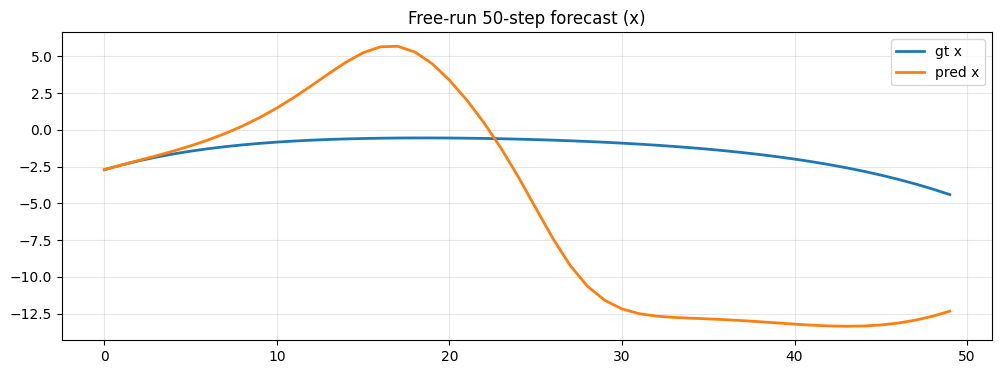

In [4]:
# One-step test evaluation
y_pred_std = gs.predict(X_test_std).astype(np.float32)
y_pred = y_scaler.inverse_transform(y_pred_std)

mse_one_step = mean_squared_error(y_test, y_pred)
print("One-step Test MSE (original scale):", mse_one_step)

# Multi-step free-run evaluation
K = 50
x0_seq = X_test[0]
preds_free = rollout_free_run(gs, x0_seq, K, x_scaler, y_scaler)

# Build ground truth for comparison
train_windows = X_train.shape[0]
seq_len = X_test.shape[1]
washout = WASHOUT
t0_global = washout + train_windows
gt_start = t0_global + seq_len
gt = data[gt_start : gt_start + K]

mse_free = mean_squared_error(gt, preds_free)
print(f"{K}-step Free-run MSE (original scale): {mse_free:.6f}")

# Plot
plt.figure(figsize=(12,4))
plt.plot(gt[:,0], label='gt x', lw=2)
plt.plot(preds_free[:,0], label='pred x', lw=2)
plt.title(f'Free-run {K}-step forecast (x)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()
